# 실습 6-1 : Clustering (K-Means, DBSCAN)

#### **<실습 내용>**

1. K-Means, DBSCAN 이해하기

2. Clustering 기반 RCA
- 반도체 공정 데이터 적용
- 연속형 변수 기반 클러스터링 (K-Means, DBSCAN)
- 연속형 + 범주형 기반 클러스터링 (K-Means, DBSCAN)

3. Vibe Coding 실습
- 통신사 고객 이탈 데이터 활용

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OS별 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.datasets import make_blobs, make_moons  # 개념 설명용 가상 데이터 생성 함수

from sklearn.preprocessing import StandardScaler  # 변수 스케일링 (거리 기반 알고리즘엔 필수)
from sklearn.cluster import KMeans, DBSCAN        # 군집화 알고리즘 2종
from sklearn.metrics import silhouette_score       # 군집이 잘 나뉘었는지 점수로 평가하는 지표
from collections import Counter

---

## 1) K-Means, DBSCAN 이해하기

### 1-1) 가상 데이터 만들기

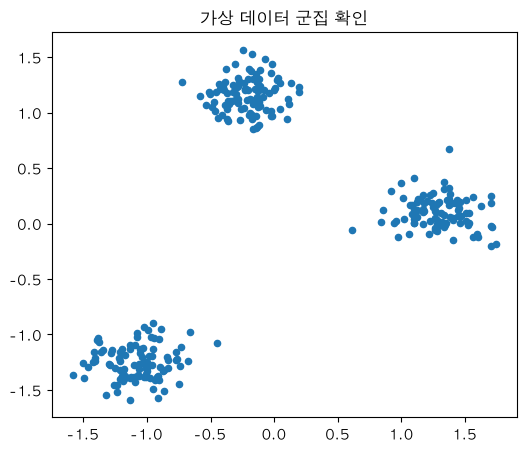

In [2]:
# make_blobs: 3개의 중심을 기준으로 뭉쳐진 가상 데이터 300개를 생성
# 군집이 몇 개인지 이미 아는 상태에서 알고맂므이 3개 군집을 잘 찾아내는지 확인하기 위함

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.title("가상 데이터 군집 확인")
plt.show()

### 1-2) K-Means

> **K-Means**는 K개 군집의 중심(Centroid)을 반복적으로 갱신하여 데이터를 가장 가까운 군집에 배정하는 알고리즘임
> 1. 초기 K개의 중심을 선정 (기본값: `init='k-means++'`, 서로 멀리 떨어진 점들을 초기 중심으로 골라 랜덤 초기화보다 안정적인 결과를 줌)
> 2. 각 데이터를 가장 가까운 중심에 배정
> 3. 각 군집의 중심을 재계산
> 4. 중심이 변하지 않을 때까지 2-3 반복

In [3]:
# 1) 기본 K-Means: K를 임의로 3으로 지정하고 학습
# n_clusters: 생성할 군집수
# n_init: 초기 중심점을 몇 번 다르게 랜덤 배치해서 시도할지 
#         (10이면 10번 시도 후 가장 좋은 결과 채택)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# 데이터별 군집 학습 및 군집 번호 예측
cluster = kmeans.fit_predict(X)
cluster

array([1, 1, 2, 0, 1, 3, 2, 3, 2, 2, 2, 3, 2, 2, 1, 2, 1, 0, 2, 2, 2, 2,
       3, 1, 2, 4, 1, 0, 3, 2, 2, 2, 4, 2, 1, 2, 4, 3, 1, 3, 3, 2, 1, 0,
       2, 2, 4, 0, 4, 3, 3, 4, 4, 2, 4, 3, 4, 2, 3, 2, 4, 3, 3, 4, 1, 0,
       0, 4, 1, 2, 3, 4, 1, 2, 2, 4, 1, 0, 2, 3, 2, 2, 4, 2, 3, 4, 4, 2,
       3, 2, 1, 2, 4, 2, 2, 1, 1, 2, 1, 4, 0, 2, 0, 2, 2, 2, 2, 2, 3, 1,
       3, 2, 2, 2, 2, 3, 1, 0, 1, 0, 3, 3, 2, 4, 4, 1, 4, 2, 4, 1, 2, 2,
       2, 2, 2, 3, 0, 1, 2, 1, 2, 2, 4, 2, 0, 0, 3, 2, 3, 2, 2, 4, 3, 1,
       2, 0, 3, 1, 4, 2, 2, 1, 4, 4, 2, 4, 0, 2, 2, 2, 2, 2, 0, 2, 0, 3,
       3, 2, 3, 3, 4, 2, 1, 3, 3, 1, 3, 2, 0, 0, 4, 4, 0, 1, 0, 0, 3, 3,
       2, 4, 2, 2, 0, 0, 2, 3, 1, 1, 3, 2, 2, 1, 3, 0, 4, 4, 4, 4, 2, 1,
       4, 0, 1, 1, 2, 0, 1, 4, 0, 2, 2, 4, 2, 1, 3, 3, 1, 3, 4, 1, 4, 3,
       3, 2, 4, 0, 3, 3, 4, 3, 4, 0, 1, 3, 3, 4, 0, 2, 1, 2, 2, 2, 4, 2,
       3, 0, 4, 3, 3, 2, 2, 3, 0, 3, 4, 4, 1, 2, 2, 2, 0, 3, 3, 0, 4, 3,
       4, 3, 0, 4, 2, 0, 3, 2, 1, 2, 0, 2, 4, 4], d

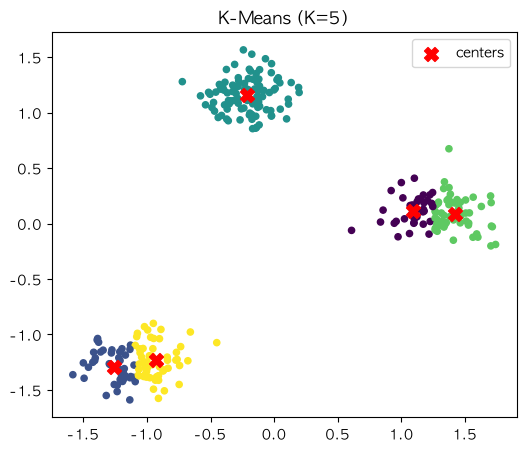

In [4]:
plt.figure(figsize=(6, 5))  

# c: 각 점의 색상을 지정하는 값 (여기선 군집 번호로 색 구분)
# labels_: 각 데이터가 어느 군집에 배정됐는지 (fit_predict 결과와 동일)
# s: 점 크기
# cmap: 색상 팔레트 (viridis는 연속형 색상 매핑)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')

# cluster_centers_: 학습된 각 군집의 중심 좌표
# c='red': 중심점 색상 고정
# marker='X': 점 모양을 X자로 표시 
# s=200: 중심점은 크게 표시해서 눈에 띄게 함
# label='centers': 범례(legend)에 표시될 이름

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=100, label='centers')

plt.title("K-Means (K=5)")  
plt.legend()  
plt.show()

#### K 값에 따른 결과 비교

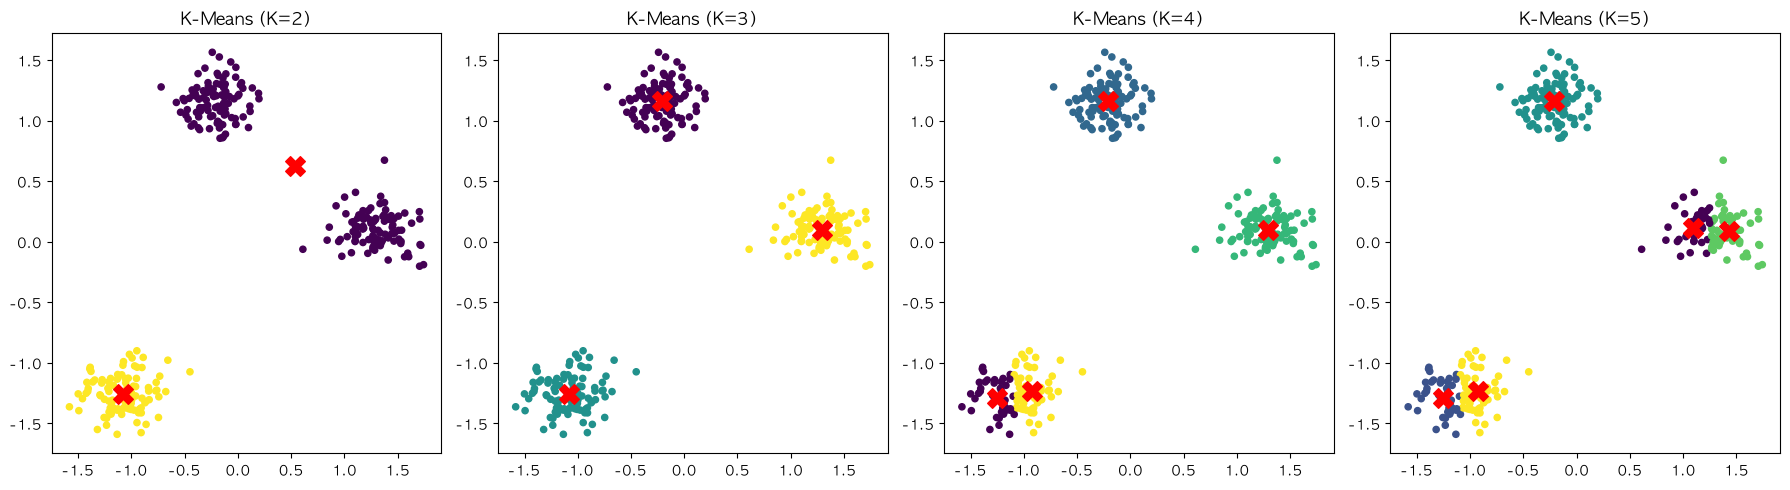

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, k in zip(axes, [2, 3, 4, 5]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')  # labels_: 각 데이터가 배정된 군집 번호
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)  # cluster_centers_: 학습된 군집 중심 좌표
    ax.set_title(f"K-Means (K={k})")

plt.tight_layout()
plt.show()

#### Silhouette Method로 최적 K 결정

> **Silhouette Score**는 각 데이터가 자신이 속한 군집과 얼마나 잘 맞는지를 측정함
> - 1에 가까울수록 올바른 군집
> - K를 변화시키며 평균 Silhouette Score가 최대인 K를 선택

In [6]:
sil_scores = []
K_range = range(2, 10)  # K를 2~9까지 바꿔가며 비교

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit_predict(X)
    # silhouette_score: 군집이 얼마나 잘 나뉘었는지를 -1~1 사이 숫자로 요약
    # 1에 가까울수록 좋음
    sil_scores.append(silhouette_score(X, kmeans.labels_))

best_k = K_range[np.argmax(sil_scores)]  # 점수가 가장 높은 K를 최적 K로 선택
print(f"최적 K: {best_k} (Silhouette Score: {max(sil_scores):.3f})")

최적 K: 3 (Silhouette Score: 0.848)


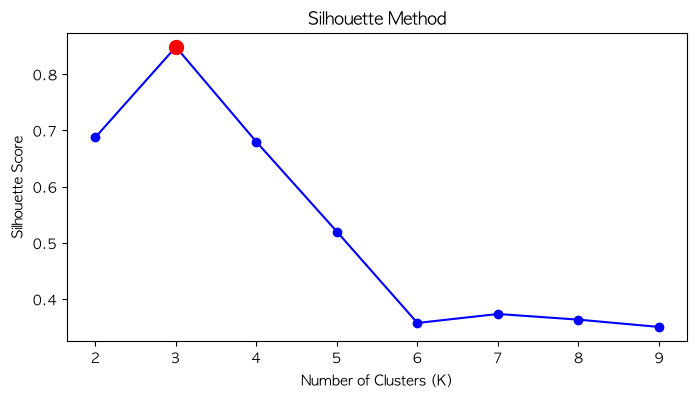

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')  # K별 실루엣 점수 선 그래프

# best_k 지점만 빨간 점으로 강조 표시
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)

plt.xlabel("Number of Clusters (K)")    # x축 라벨: K 값
plt.ylabel("Silhouette Score")          # y축 라벨: 실루엣 점수 (1에 가까울수록 군집 잘 나뉨)
plt.title("Silhouette Method")         
plt.xticks(K_range)                  
plt.show()

---

### 1-3) DBSCAN

> **DBSCAN**은 밀도 기반 클러스터링으로 데이터가 많이 모여 있는 영역을 하나의 군집으로 인식하는 방법임 (군집 수를 미리 지정할 필요가 없음)
>
> - **eps**: 이웃으로 인정할 최대 거리
> - **min_samples**: 하나의 군집으로 인정하기 위한 최소 이웃 수
> - **Core Point**: 주변에 이웃이 충분히 많은 중심 데이터
> - **Border Point**: 군집 가장자리에 위치한 데이터
> - **Noise Point**: 어떤 군집에도 속하지 않는 이상치 데이터 (label = -1)
>
> DBSCAN은 이상 탐지에도 유용함

In [8]:
# eps: 이웃으로 인정할 최대 거리 (이 반경 안에 점이 몰려있으면 같은 군집)
# min_samples: 하나의 군집으로 인정하기 위한 최소 이웃 수
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 데이터별 군집 학습 및 군집 번호 예측
# DBSCAN은 K-Means와 달리 노이즈(어느 군집에도 속하지 않는 점)를 -1로 표시
cluster = dbscan.fit_predict(X)
cluster

array([0, 0, 1, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 1, 1, 1, 1,
       2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 2, 1, 0, 2,
       1, 1, 0, 2, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2,
       2, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1,
       2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0,
       2, 1, 1, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 1, 0, 2, 0,
       1, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2,
       1, 0, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 1, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2,
       2, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1, 0, 1, 1, 1, 0, 1,
       2, 2, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0])

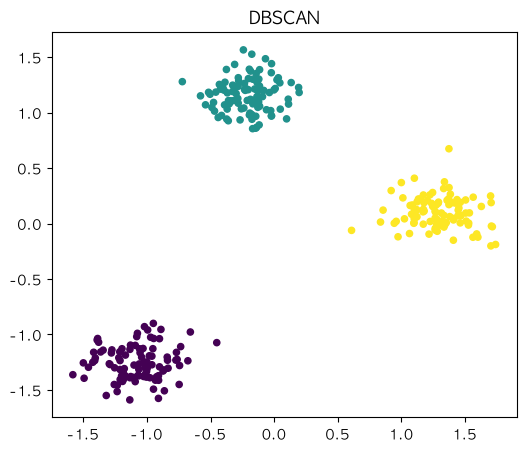

In [9]:
plt.figure(figsize=(6, 5))

# c: 군집 번호로 색 구분 (-1은 노이즈, 보통 다른 색으로 튐)
plt.scatter(X[:, 0], X[:, 1], c=cluster, s=20, cmap='viridis')
plt.title("DBSCAN")
plt.show()

#### eps 값에 따른 결과 비교

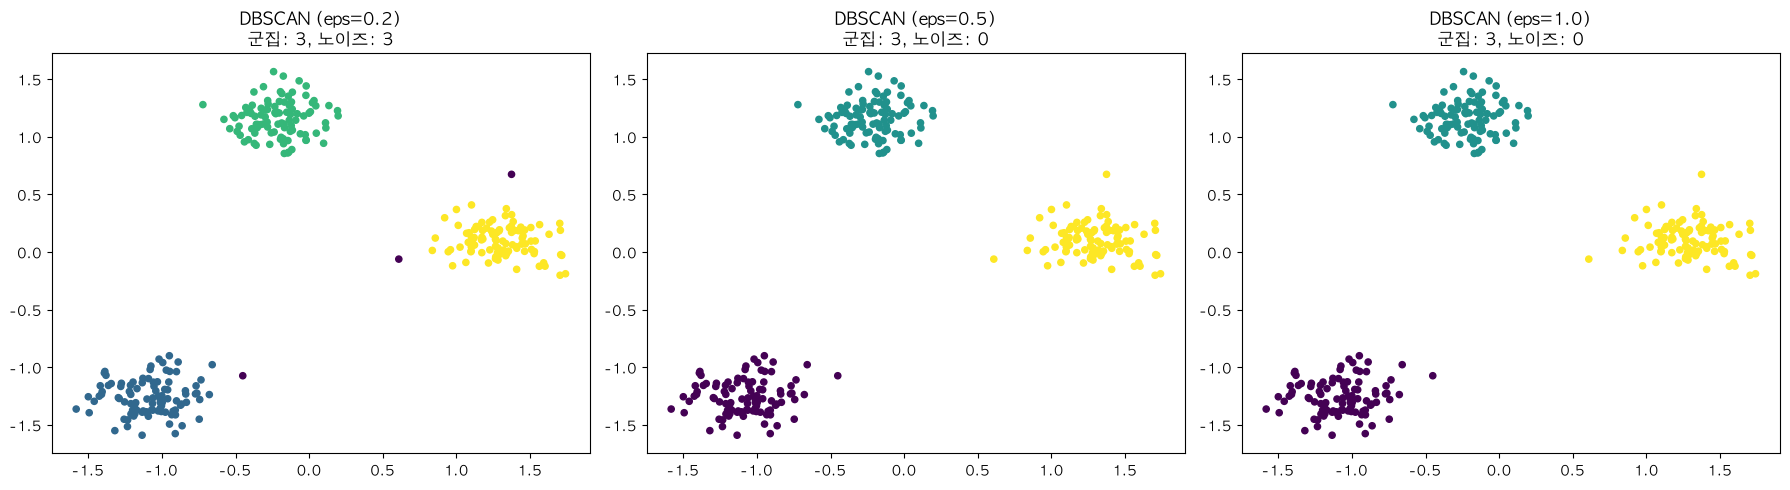

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, [0.2, 0.5, 1.0]):
    # eps: 이웃으로 인정할 반경 / min_samples: Core Point가 되기 위한 최소 이웃 수
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)  # 라벨 -1(노이즈)은 군집 수에서 제외하고 계산
    n_noise = list(dbscan.labels_).count(-1)  # 어떤 군집에도 속하지 못한 노이즈 데이터 개수

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

#### K-distance Plot으로 최적 eps 결정

> **eps** : 두 데이터를 이웃으로 판단하기 위한 최대 거리

- **K-distance Plot**
  - 각 데이터의 K번째 최근접 이웃까지의 거리를 계산한 후, 이를 오름차순으로 정렬하여 나타낸 그래프

- **eps 선택 방법**
  - 그래프에서 거리가 급격히 증가하기 시작하는 지점(Elbow Point)의 거리 값을 eps로 선택

- **해석**
  - 그래프가 완만한 구간 → 군집 내부 데이터
  - 그래프가 급격히 상승하는 구간 → 이상치(Noise) 후보
  - Elbow Point의 y값 → 적절한 eps 후보

- **의미**
  - Elbow Point 이전의 데이터는 군집에 속할 가능성이 높음
  - Elbow Point 이후의 데이터는 이상치(Noise)일 가능성이 높음

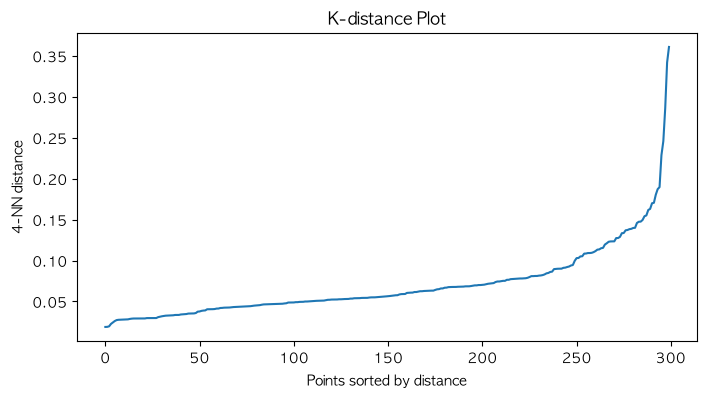

In [11]:
from sklearn.neighbors import NearestNeighbors

# min_samples를 먼저 정해야 k-distance 계산 가능 
# 보통 min_samples = 데이터 차원수*2
# 현재 예시는 2차원이니 min_samples=4~5 근처로 시작

min_samples = 4

# 각 점마다 자신을 포함해 min_samples번째로 가까운 이웃까지의 거리 계산
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# min_samples번째 이웃까지의 거리만 추출 후 오름차순 정렬
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot")
plt.show()

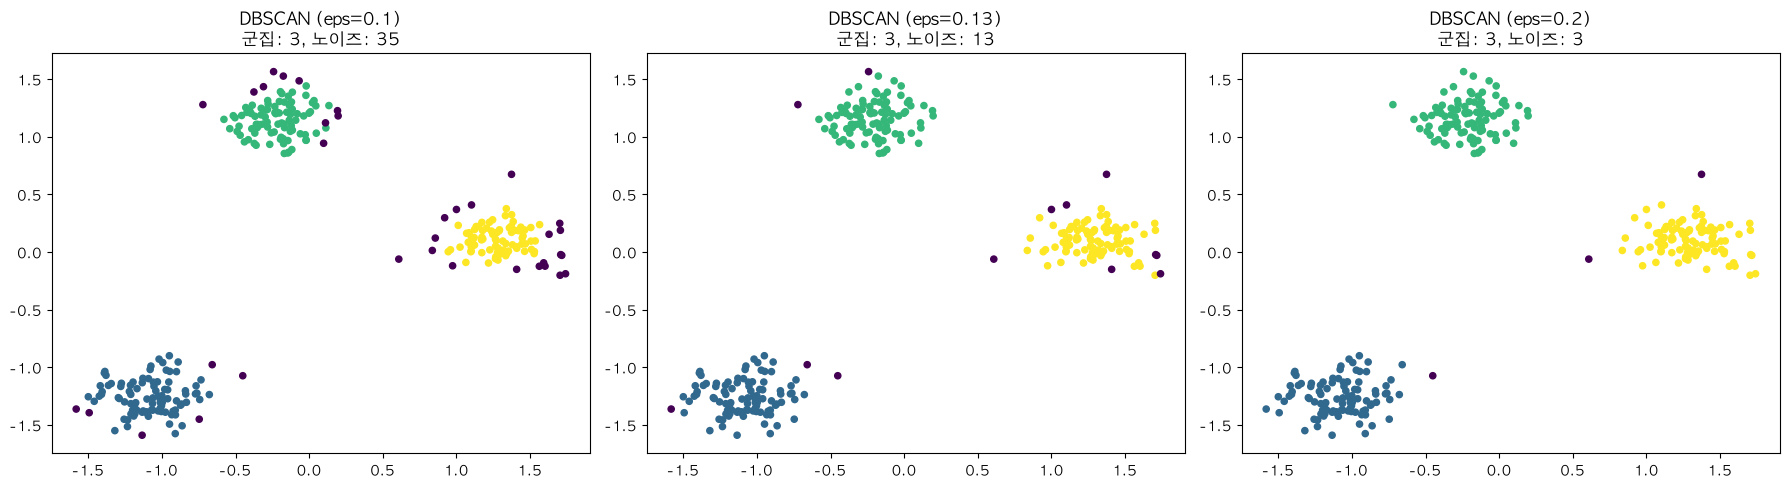

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-distance plot의 기준으로 주변 최적의 eps 후보 비교
for ax, eps in zip(axes, [0.1, 0.13, 0.2]):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
    n_noise = list(dbscan.labels_).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

### 1-4) 비선형 데이터에서 K-Means vs DBSCAN

> DBSCAN은 다양한 모양의 군집을 형성할 수 있어 K-Means가 잘 작동하지 않는 비선형 데이터에서 강점을 보임

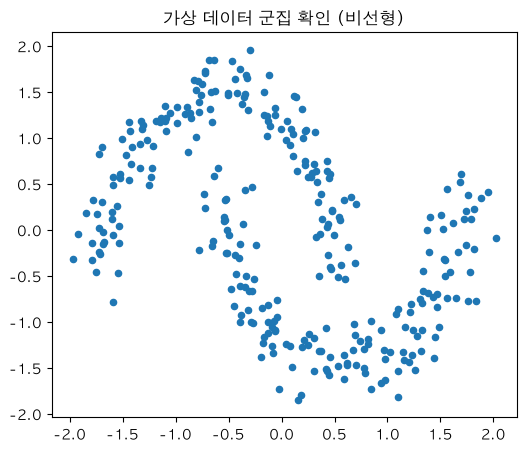

In [13]:
# 1) 가상 데이터 만들기
# make_moons: 초승달 모양 2개가 맞물린 비선형 데이터 
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X_moon = StandardScaler().fit_transform(X_moon)

plt.figure(figsize=(6, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], s=20)
plt.title("가상 데이터 군집 확인 (비선형)")
plt.show()

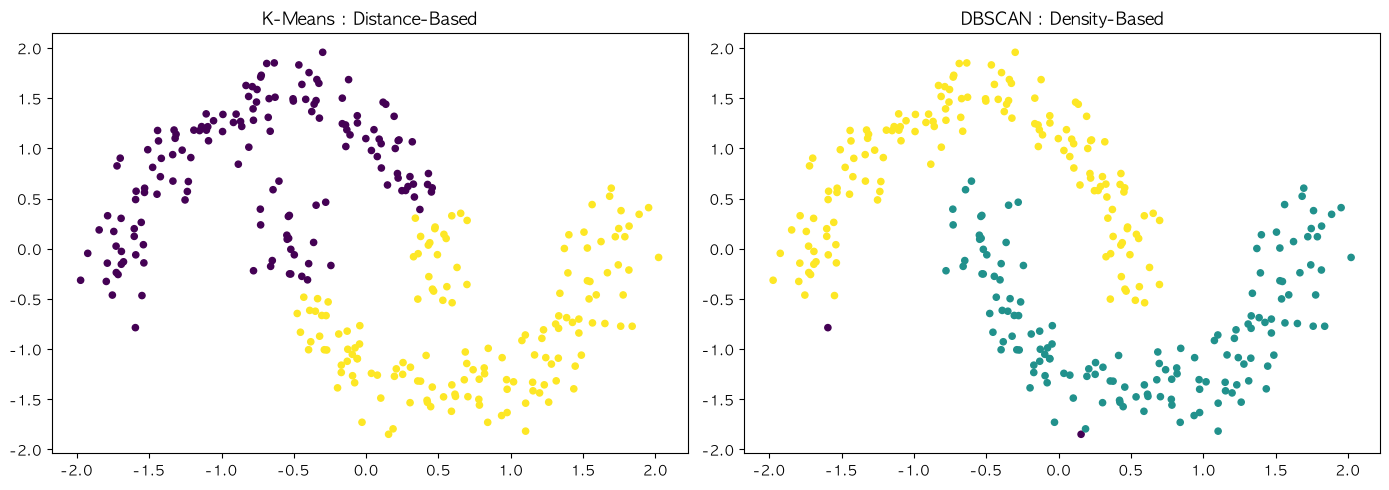

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means: '중심까지의 거리'만 고려함
kmeans_moon = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans_moon.fit_predict(X_moon)
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans_moon.labels_, s=20, cmap='viridis')
axes[0].set_title("K-Means : Distance-Based")

# DBSCAN: '밀도가 이어지는지'로 판단함
dbscan_moon = DBSCAN(eps=0.3, min_samples=5)
dbscan_moon.fit_predict(X_moon)
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=dbscan_moon.labels_, s=20, cmap='viridis')
axes[1].set_title("DBSCAN : Density-Based")

plt.tight_layout()
plt.show()

## 2) Clustering 기반 RCA 수행

**활용할 반도체 공정 데이터 소개**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

In [15]:
data = pd.read_csv("dataset/day6-1_data.csv")

# 조건 기반 타겟변수 생성
data["Fail"] = ["Fault" if y >= 3 else "Pass" for y in data["Y"]]
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 13)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass


In [16]:
print(data["Fail"].value_counts())

Fail
Pass     471
Fault    125
Name: count, dtype: int64


### 2-1) 연속형 변수만 활용한 경우

In [17]:
num_cols = ["C1", "C2"]

# 거리 기반 알고리즘이므로 표준화 필수
X_num = StandardScaler().fit_transform(data[num_cols])

#### K-Menas

> Silhouette 기반 최적 K 찾기

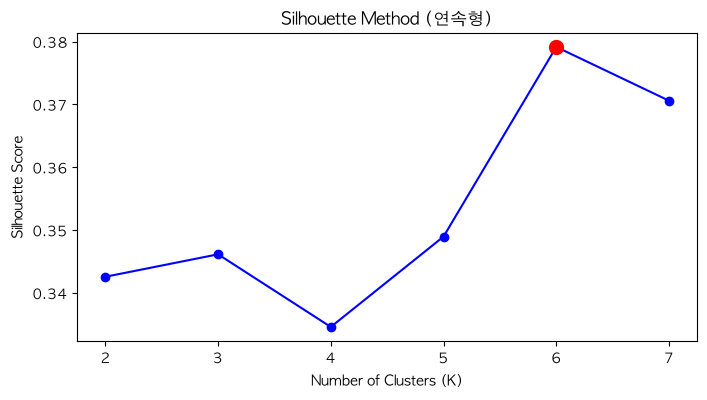

최적 K: 6


In [18]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_num)
    score = silhouette_score(X_num, labels)  # 군집이 잘 나뉠수록 1에 가까움
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]  # 실루엣 점수가 가장 높은 K

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

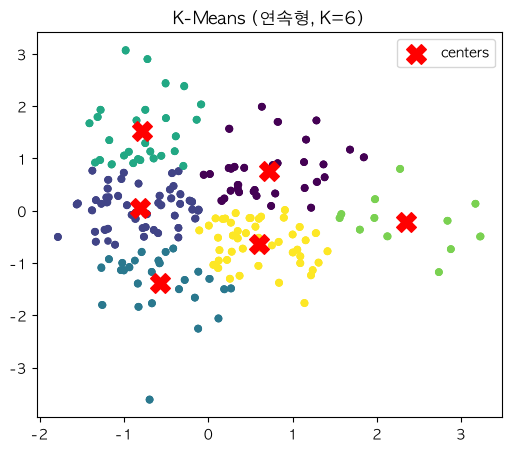

In [19]:
# 최적 K로 최종 K-Means 학습
kmeans_num = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_num"] = kmeans_num.fit_predict(X_num)

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_kmeans_num"], s=20, cmap='viridis')
plt.scatter(kmeans_num.cluster_centers_[:, 0], kmeans_num.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='centers')
plt.title(f"K-Means (연속형, K={best_k})")
plt.legend()
plt.show()

#### DBSCAN

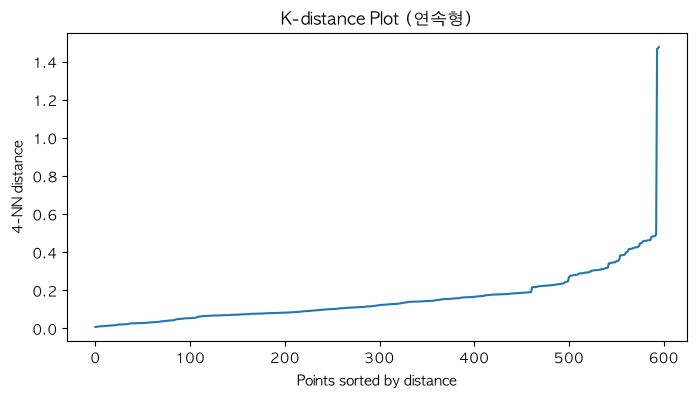

In [20]:
min_samples = 4  # 2차원 데이터 기준 통상 4~5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_num)
distances, indices = neighbors_fit.kneighbors(X_num)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형)")
plt.show()

군집 수: 7, 노이즈: 33


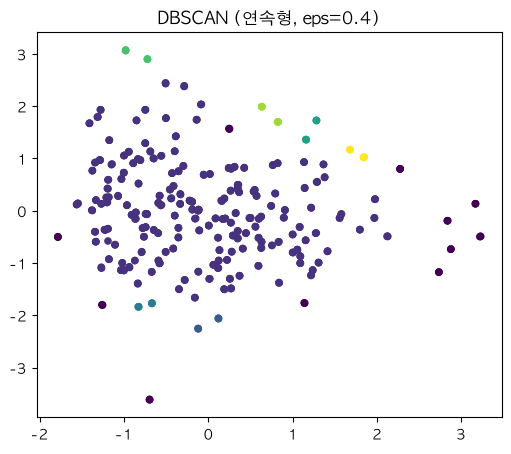

In [21]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_num = 0.4 

dbscan_num = DBSCAN(eps=eps_num, min_samples=min_samples)
data["cluster_dbscan_num"] = dbscan_num.fit_predict(X_num)

n_clusters = len(set(data["cluster_dbscan_num"])) - (1 if -1 in data["cluster_dbscan_num"].values else 0)
n_noise = (data["cluster_dbscan_num"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_dbscan_num"], s=20, cmap='viridis')
plt.title(f"DBSCAN (연속형, eps={eps_num})")
plt.show()

#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형 변수 값 비교

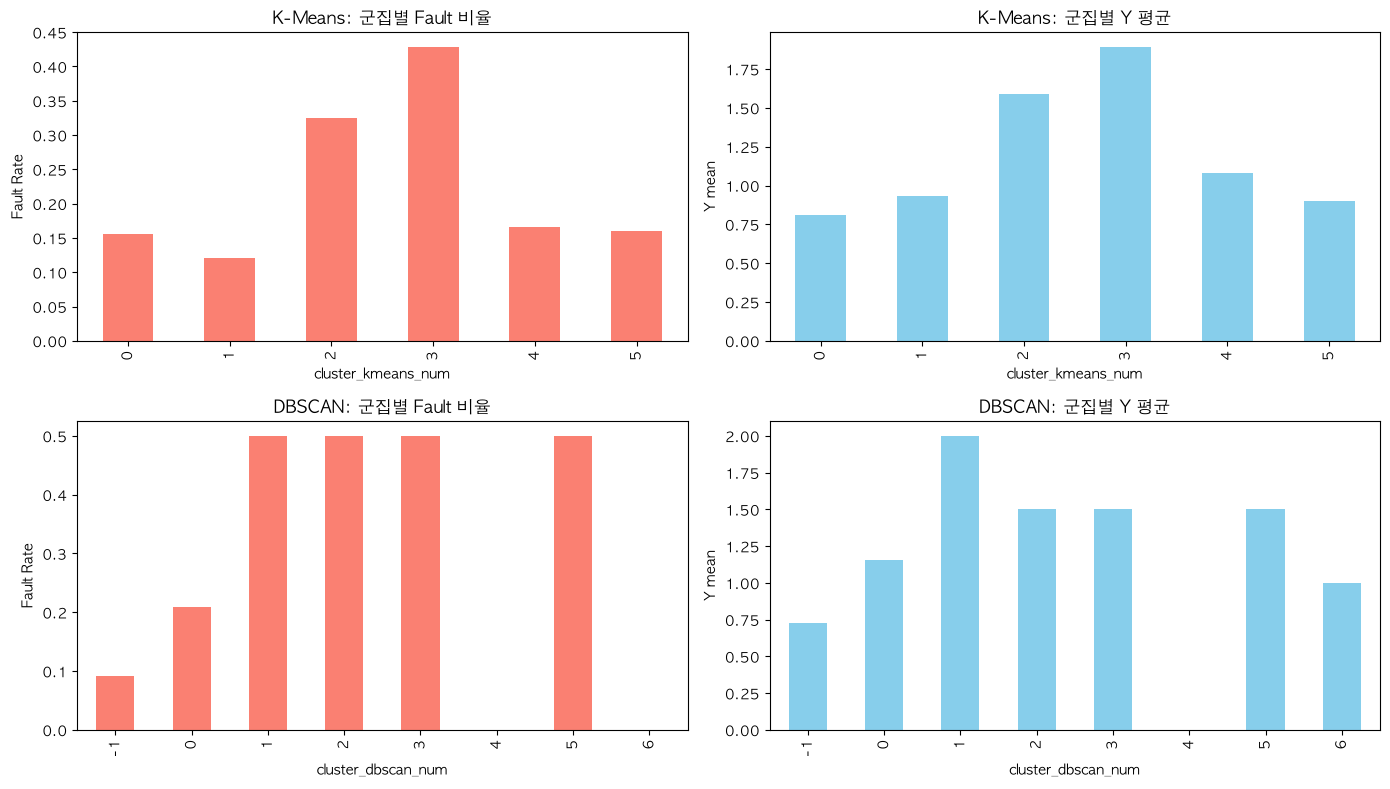

In [22]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# K-Means: 군집별 Fault 비율
kmeans_fault_rate = data.groupby("cluster_kmeans_num")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means: 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

# K-Means: 군집별 Y 평균
data.groupby("cluster_kmeans_num")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means: 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

# DBSCAN: 군집별 Fault 비율
dbscan_fault_rate = data.groupby("cluster_dbscan_num")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN: 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

# DBSCAN: 군집별 Y 평균
data.groupby("cluster_dbscan_num")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN: 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

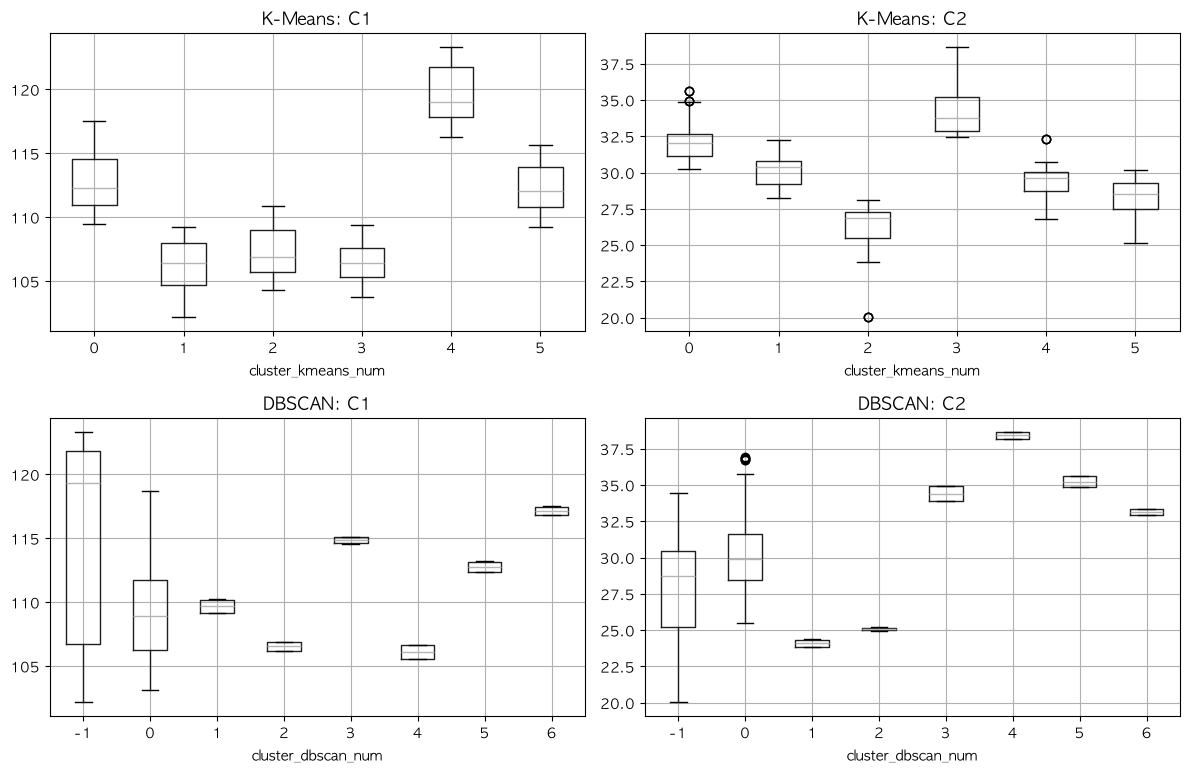

In [23]:
# 2. 군집별 연속형 변수(C1, C2) 값 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data.boxplot(column="C1", by="cluster_kmeans_num", ax=axes[0, 0])
axes[0, 0].set_title("K-Means: C1")

data.boxplot(column="C2", by="cluster_kmeans_num", ax=axes[0, 1])
axes[0, 1].set_title("K-Means: C2")

data.boxplot(column="C1", by="cluster_dbscan_num", ax=axes[1, 0])
axes[1, 0].set_title("DBSCAN: C1")

data.boxplot(column="C2", by="cluster_dbscan_num", ax=axes[1, 1])
axes[1, 1].set_title("DBSCAN: C2")

plt.suptitle("")  # boxplot 자동 상위 제목 제거
plt.tight_layout()
plt.show()

---

### 2-2) 모든 변수를 활용한 경우

In [24]:
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
num_cols = ["C1", "C2"]

# 범주형은 원-핫 인코딩, 연속형은 표준화해서 하나의 행렬로 합침
X_cat = pd.get_dummies(data[cat_cols].astype("object"))
X_cat[num_cols] = StandardScaler().fit_transform(data[num_cols])

#### K-Means

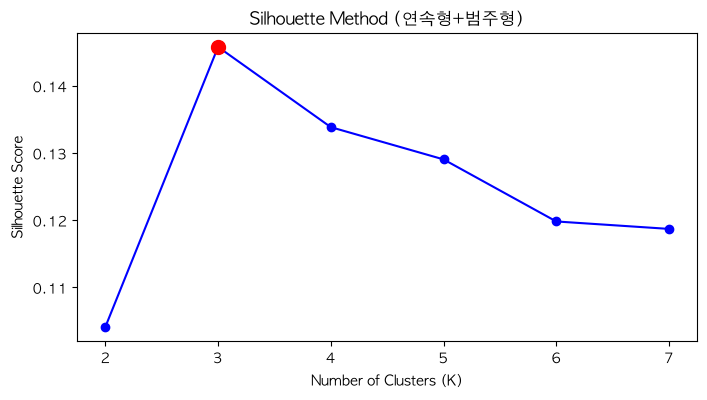

최적 K: 3


In [25]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cat)
    score = silhouette_score(X_cat, labels)
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형+범주형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

In [26]:
kmeans_full = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_full"] = kmeans_full.fit_predict(X_cat)

#### DBSCAN

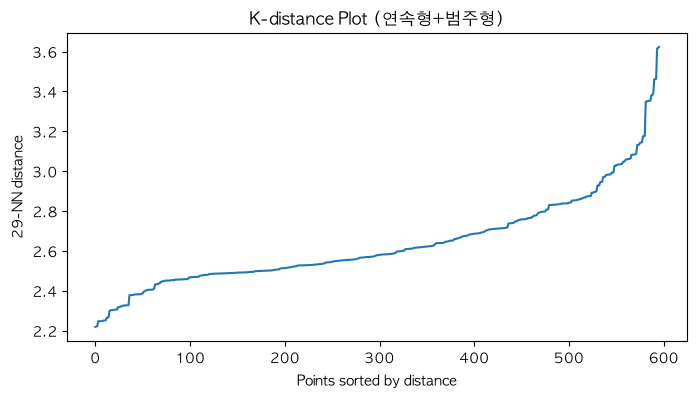

In [27]:
min_samples = X_cat.shape[1] + 1  # 차원이 늘어났으니 min_samples도 늘림

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cat)
distances, indices = neighbors_fit.kneighbors(X_cat)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형+범주형)")
plt.show()

In [28]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_full = 2.7

dbscan_full = DBSCAN(eps=eps_full, min_samples=min_samples)
data["cluster_dbscan_full"] = dbscan_full.fit_predict(X_cat)

n_clusters = len(set(data["cluster_dbscan_full"])) - (1 if -1 in data["cluster_dbscan_full"].values else 0)
n_noise = (data["cluster_dbscan_full"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

군집 수: 1, 노이즈: 24


#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형/범주형 변수 값 비교

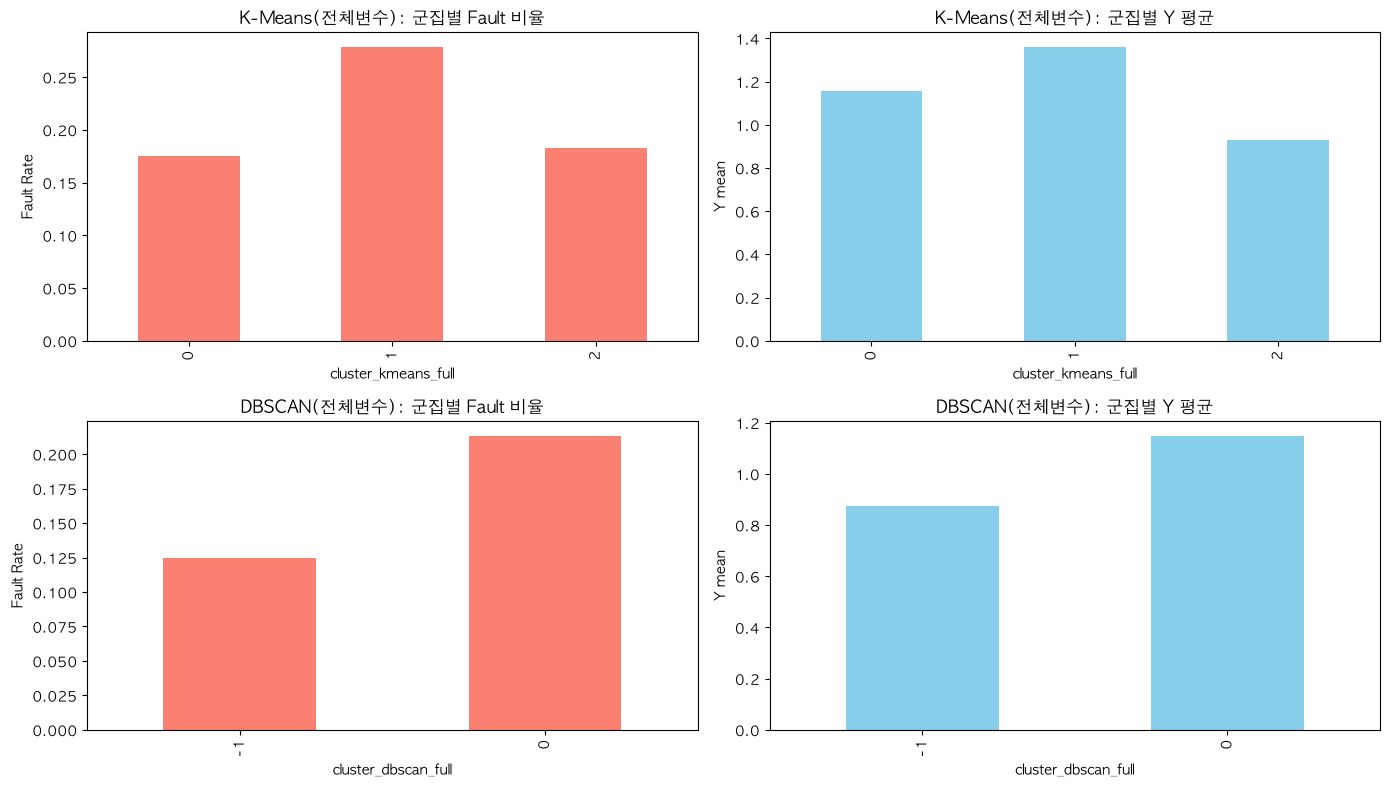

In [29]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

kmeans_fault_rate = data.groupby("cluster_kmeans_full")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means(전체변수): 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

data.groupby("cluster_kmeans_full")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means(전체변수): 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

dbscan_fault_rate = data.groupby("cluster_dbscan_full")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN(전체변수): 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

data.groupby("cluster_dbscan_full")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN(전체변수): 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

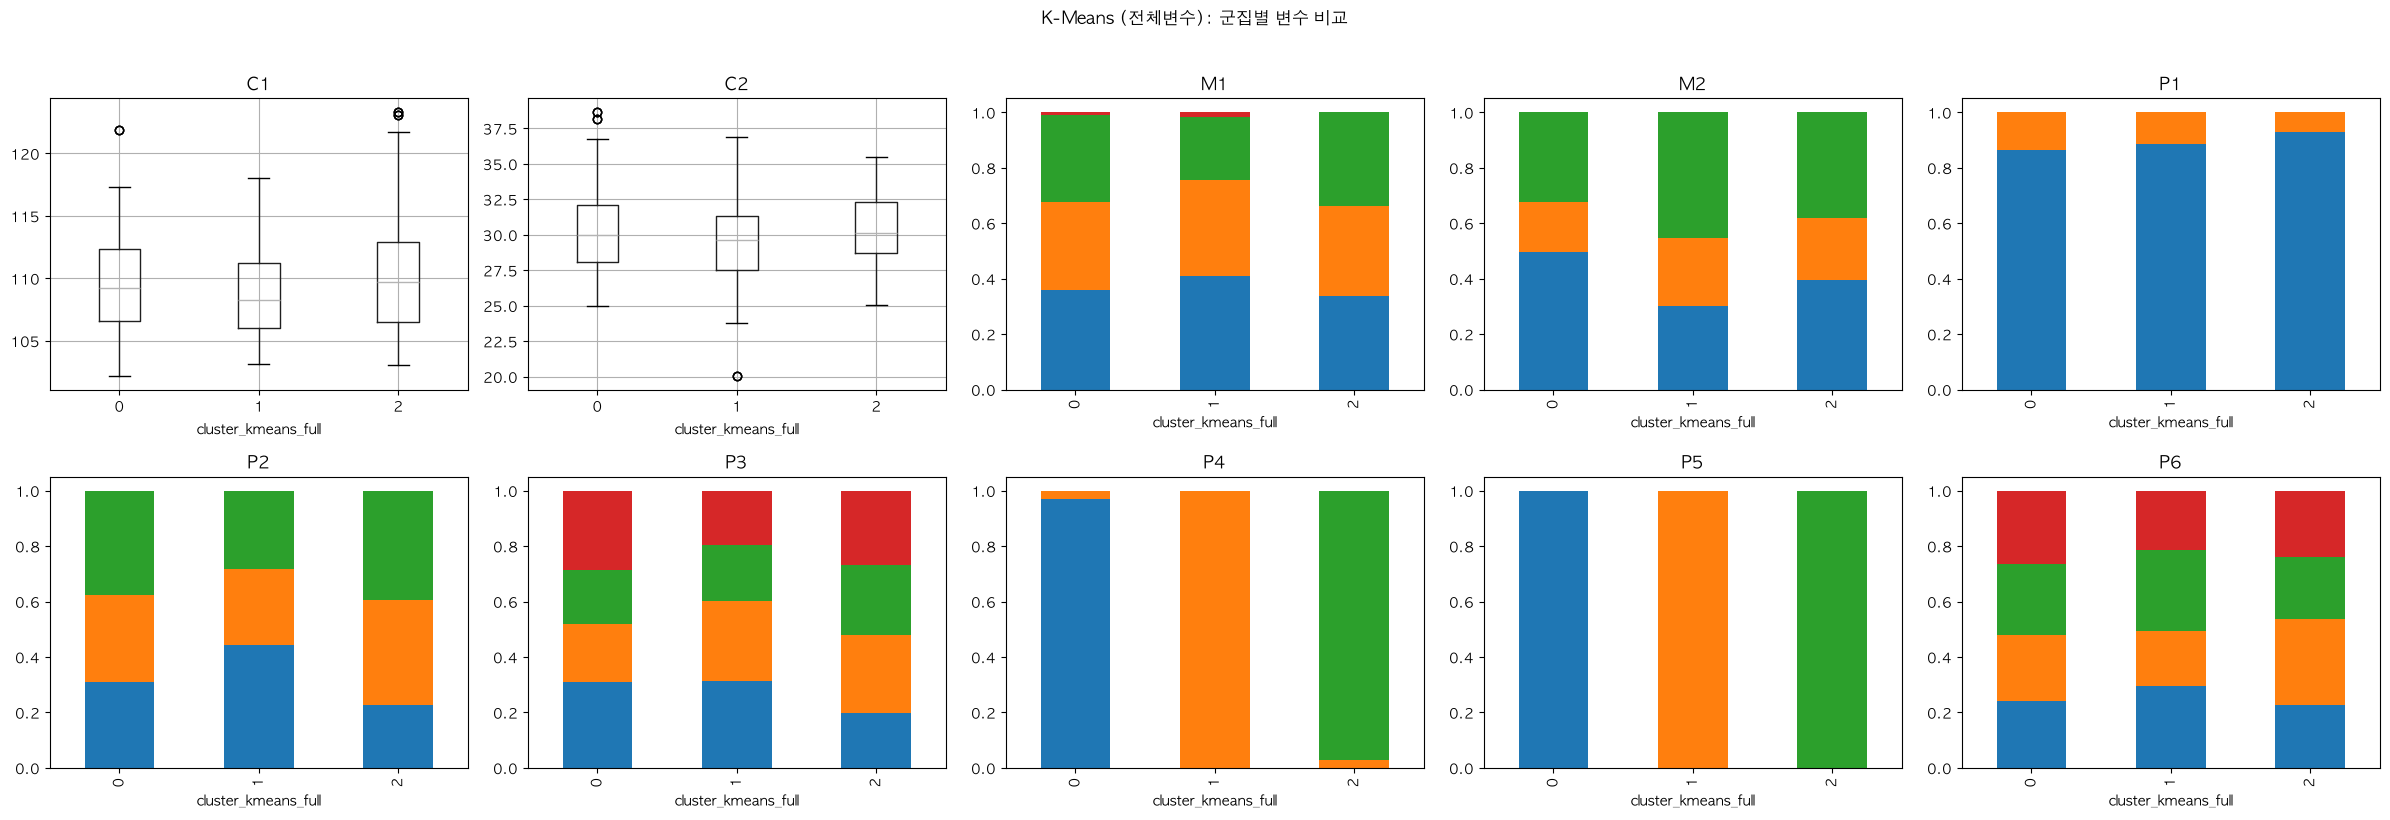

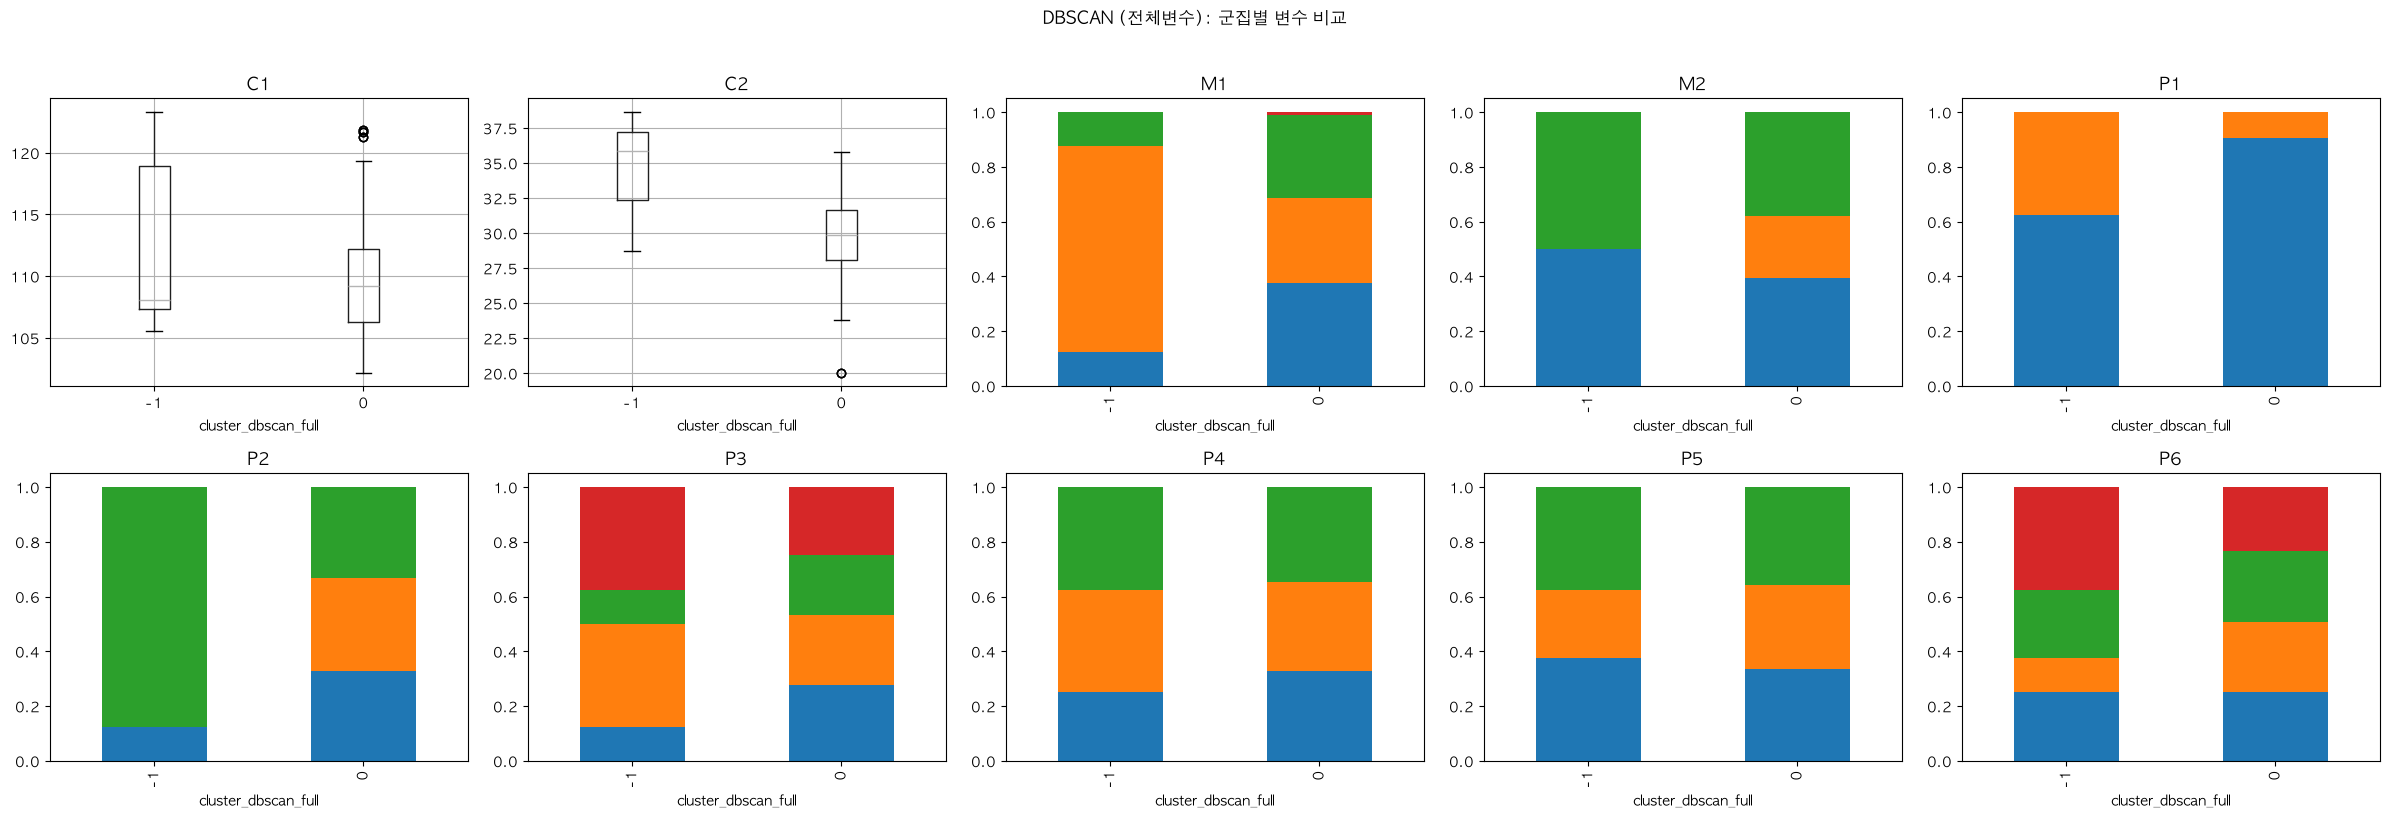

In [30]:
# 2. 군집별 연속형/범주형 변수 값 비교 

# 1) K-Means
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

# 연속형 2개
data.boxplot(column="C1", by="cluster_kmeans_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_kmeans_full", ax=axes[1])
axes[1].set_title("C2")

# 범주형 8개
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_kmeans_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("K-Means (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

# 2) DBSCAN
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

data.boxplot(column="C1", by="cluster_dbscan_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_dbscan_full", ax=axes[1])
axes[1].set_title("C2")

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_dbscan_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("DBSCAN (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

---

## 3) Vibe Coding 실습

K-Means, DBSCAN을 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [31]:
# 필요한 라이브러리 호출하기
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.286412,0,1,-1.173697,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.069187,1,0,-0.265601,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.245333,1,1,-0.369479,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.521054,0,0,-0.756509,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.245333,1,1,0.195149,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


### 3-1) K-Means Clustering

**[과제]**

Silhouette Score로 최적의 군집 수(K)를 확인하고 AI와 함께 K-Means를 학습시켜 보세요. 

이후 군집별로 tenure, MonthlyCharges, Contract 등 주요 변수의 평균/분포를 비교해 각 군집의 특징을 파악하고 고객 세그먼트로서 어떤 이름을 붙일 수 있을지 해석해 보세요.

,K,Silhouette Score,최적 K
0,2,0.2912,★
1,3,0.2796,
2,4,0.2221,
3,5,0.2008,
4,6,0.1778,
5,7,0.1580,


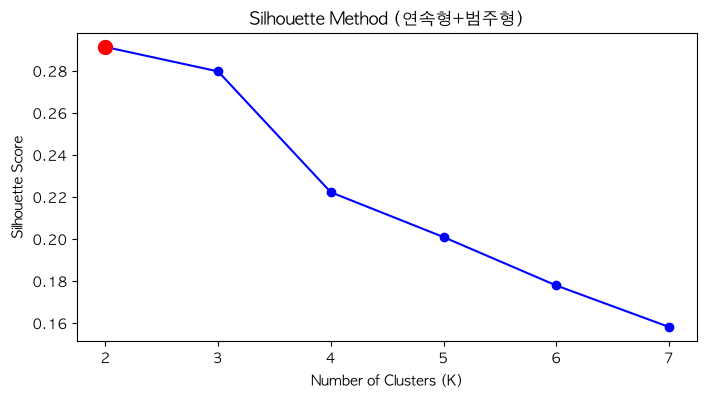

최적 K: 2

군집별 고객 수:
cluster
0    1526
1    5517
Name: count, dtype: int64


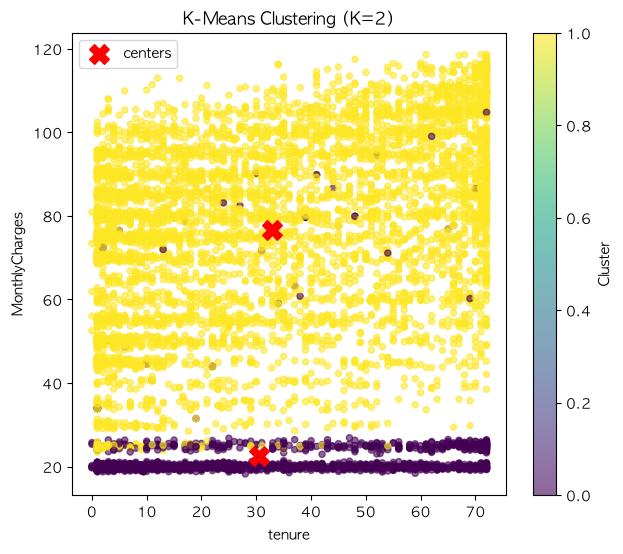


[수치형 변수 평균]


,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,30.43,22.63,668.1
1,32.84,76.56,2728.3



[군집별 이탈률 (%)]
  Cluster 0: 7.4%
  Cluster 1: 31.8%

[범주형 변수 분포 (%) ]

▶ Contract


Contract,Month-to-month,One year,Two year
cluster,,,
0,34.3,23.9,41.8
1,60.7,20.1,19.2



▶ InternetService


...

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
cluster,,,,
0,21.1,21.2,10.3,47.4
1,21.2,20.9,42.6,15.3



▶ OnlineSecurity


OnlineSecurity,No,No internet service,Yes
cluster,,,
0,0.0,100.0,0.0
1,63.4,0.0,36.6



▶ TechSupport


TechSupport,No,No internet service,Yes
cluster,,,
0,0.0,100.0,0.0
1,63.0,0.0,37.0


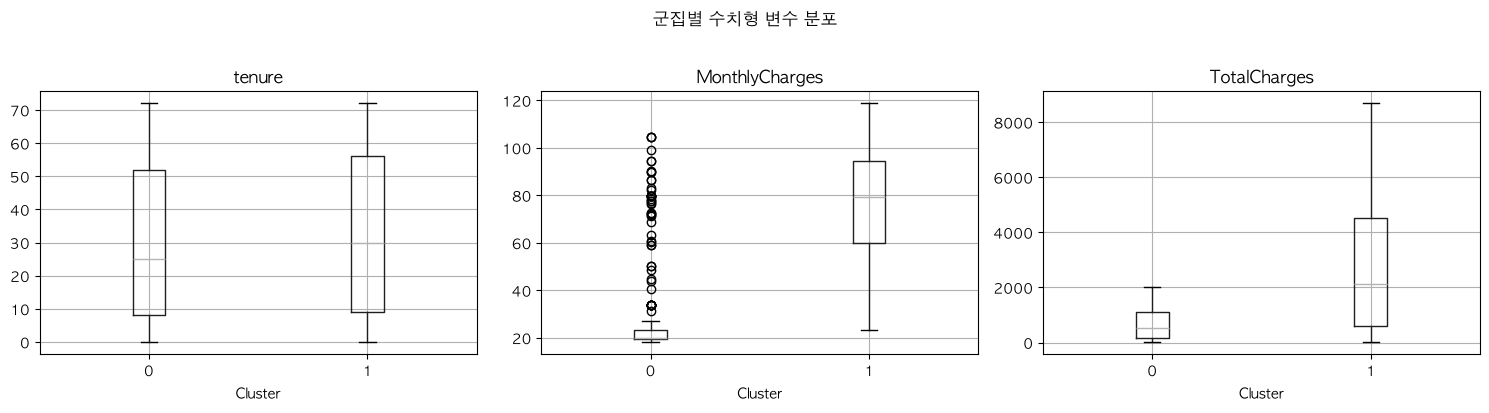

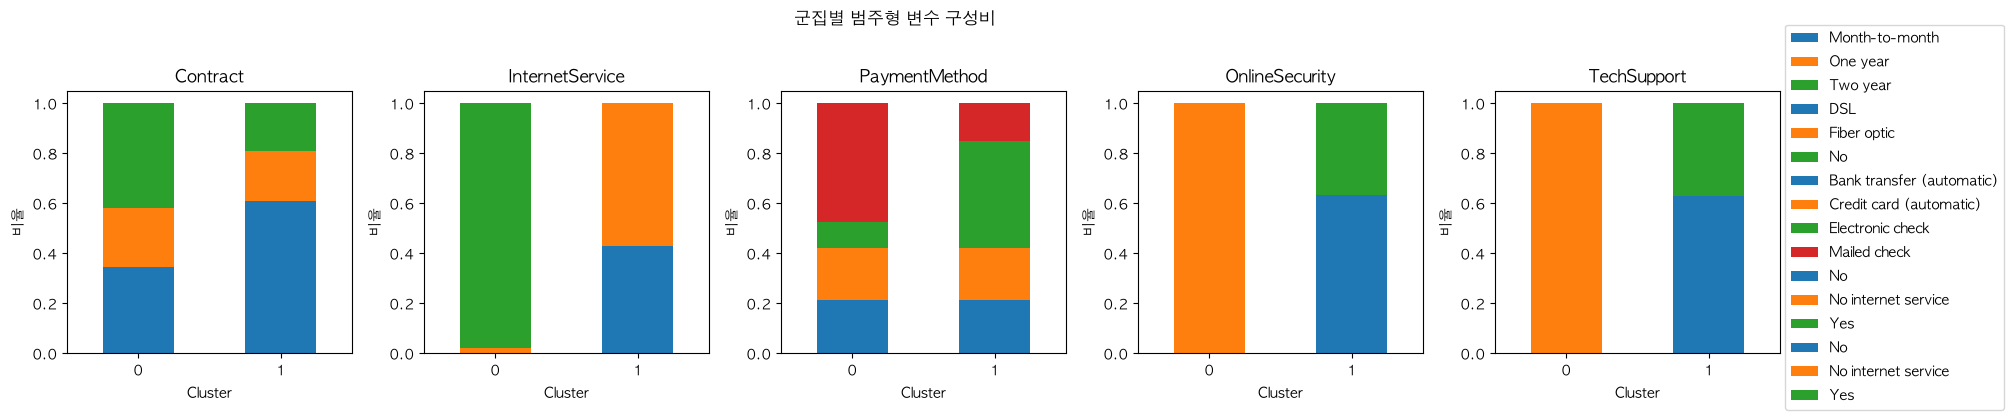


고객 세그먼트 해석

[Cluster 0]  (n=1,526, 이탈률 7.4%)
  - 평균 이용기간(tenure): 30.4개월
  - 평균 월요금(MonthlyCharges): $22.63
  - 주요 인터넷 서비스: No
  - 주요 계약 유형: Two year
  - 주요 결제 수단: Mailed check

[Cluster 1]  (n=5,517, 이탈률 31.8%)
  - 평균 이용기간(tenure): 32.8개월
  - 평균 월요금(MonthlyCharges): $76.56
  - 주요 인터넷 서비스: Fiber optic
  - 주요 계약 유형: Month-to-month
  - 주요 결제 수단: Electronic check

▶ Cluster 0 → 「기본 전화 단말 고객」
  - 인터넷 미가입(No internet service) 비율이 압도적으로 높음
  - 월요금·총요금이 낮고, 장기 계약(2년) 비율이 상대적으로 높음
  - 이탈률이 매우 낮아 안정적인 충성 고객층

▶ Cluster 1 → 「인터넷 프리미엄 고객」
  - DSL/Fiber optic 등 인터넷 서비스 가입 고객이 대부분
  - 월요금·총요금이 높고, 월 단위 계약(Month-to-month) 비율이 높음
  - 보안·기술지원 미가입 비율이 높고 이탈률이 높음 → 이탈 방지 마케팅 우선 대상



In [32]:
# ── 1) Silhouette Score로 최적 K 탐색 ──
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]

# Silhouette Score 결과 표
sil_df = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": [round(s, 4) for s in sil_scores],
})
sil_df["최적 K"] = sil_df["K"].apply(lambda k: "★" if k == best_k else "")
display(sil_df)

# Silhouette Score 시각화 (노트북 예시와 동일 스타일)
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, "bo-")
plt.scatter(best_k, max(sil_scores), c="red", s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형+범주형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

# ── 2) 최적 K로 K-Means 학습 ──
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)

print(f"\n군집별 고객 수:\n{data['cluster'].value_counts().sort_index()}")

# ── 2-1) 군집 결과 Scatter Plot (tenure vs MonthlyCharges) ──
centers = data.groupby("cluster")[["tenure", "MonthlyCharges"]].mean()

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    data["tenure"], data["MonthlyCharges"],
    c=data["cluster"], s=20, cmap="viridis", alpha=0.6,
)
plt.scatter(
    centers["tenure"], centers["MonthlyCharges"],
    c="red", marker="X", s=200, label="centers",
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("tenure")
plt.ylabel("MonthlyCharges")
plt.title(f"K-Means Clustering (K={best_k})")
plt.legend()
plt.show()

# ── 3) 군집별 주요 변수 비교 (원본 스케일 기준) ──
key_num = ["tenure", "MonthlyCharges", "TotalCharges"]
key_cat = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]

# 3-1) 수치형 변수 평균
print("\n[수치형 변수 평균]")
display(data.groupby("cluster")[key_num].mean().round(2))

# 3-2) 이탈률 (Churn: No=유지, Yes=이탈)
churn_rate = data.groupby("cluster")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
print("\n[군집별 이탈률 (%)]")
for c, rate in churn_rate.items():
    print(f"  Cluster {c}: {rate:.1f}%")

# 3-3) 범주형 변수 분포
print("\n[범주형 변수 분포 (%) ]")
for col in key_cat:
    print(f"\n▶ {col}")
    display(pd.crosstab(data["cluster"], data[col], normalize="index").round(3) * 100)

# ── 4) 시각화: 수치형 변수 분포 비교 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, key_num):
    data.boxplot(column=col, by="cluster", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
fig.suptitle("군집별 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

# ── 5) 시각화: 주요 범주형 변수 비교 ──
fig, axes = plt.subplots(1, len(key_cat), figsize=(18, 4))
for ax, col in zip(axes, key_cat):
    ct = pd.crosstab(data["cluster"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("비율")
    ax.tick_params(axis="x", rotation=0)
fig.legend(loc="center right", bbox_to_anchor=(1.12, 0.5))
plt.suptitle("군집별 범주형 변수 구성비", y=1.02)
plt.tight_layout()
plt.show()

# ── 6) 고객 세그먼트 해석 ──
print("\n" + "=" * 60)
print("고객 세그먼트 해석")
print("=" * 60)
for c in sorted(data["cluster"].unique()):
    sub = data[data["cluster"] == c]
    n = len(sub)
    churn_pct = (sub["Churn"] == "Yes").mean() * 100
    print(f"\n[Cluster {c}]  (n={n:,}, 이탈률 {churn_pct:.1f}%)")
    print(f"  - 평균 이용기간(tenure): {sub['tenure'].mean():.1f}개월")
    print(f"  - 평균 월요금(MonthlyCharges): ${sub['MonthlyCharges'].mean():.2f}")
    print(f"  - 주요 인터넷 서비스: {sub['InternetService'].value_counts().idxmax()}")
    print(f"  - 주요 계약 유형: {sub['Contract'].value_counts().idxmax()}")
    print(f"  - 주요 결제 수단: {sub['PaymentMethod'].value_counts().idxmax()}")

print("""
▶ Cluster 0 → 「기본 전화 단말 고객」
  - 인터넷 미가입(No internet service) 비율이 압도적으로 높음
  - 월요금·총요금이 낮고, 장기 계약(2년) 비율이 상대적으로 높음
  - 이탈률이 매우 낮아 안정적인 충성 고객층

▶ Cluster 1 → 「인터넷 프리미엄 고객」
  - DSL/Fiber optic 등 인터넷 서비스 가입 고객이 대부분
  - 월요금·총요금이 높고, 월 단위 계약(Month-to-month) 비율이 높음
  - 보안·기술지원 미가입 비율이 높고 이탈률이 높음 → 이탈 방지 마케팅 우선 대상
""")

### 3-2) DBSCAN 적용

**[과제]** 

AI와 함께 최적의 eps를 찾아 DBSCAN을 학습시켜 보세요.

K-Means와 결과가 어떻게 다른지, Noise로 분류된 고객들은 어떤 특징을 보이는지 확인해 보세요.

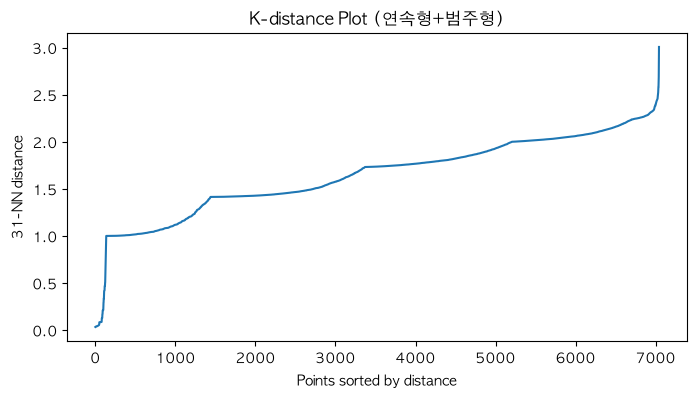

,eps,군집 수,Noise 수,Noise 비율(%),최적 eps
0,1.908,2,481,6.8,
1,2.004,2,251,3.6,
2,2.026,2,139,2.0,
3,2.059,2,44,0.6,
4,2.117,2,14,0.2,★


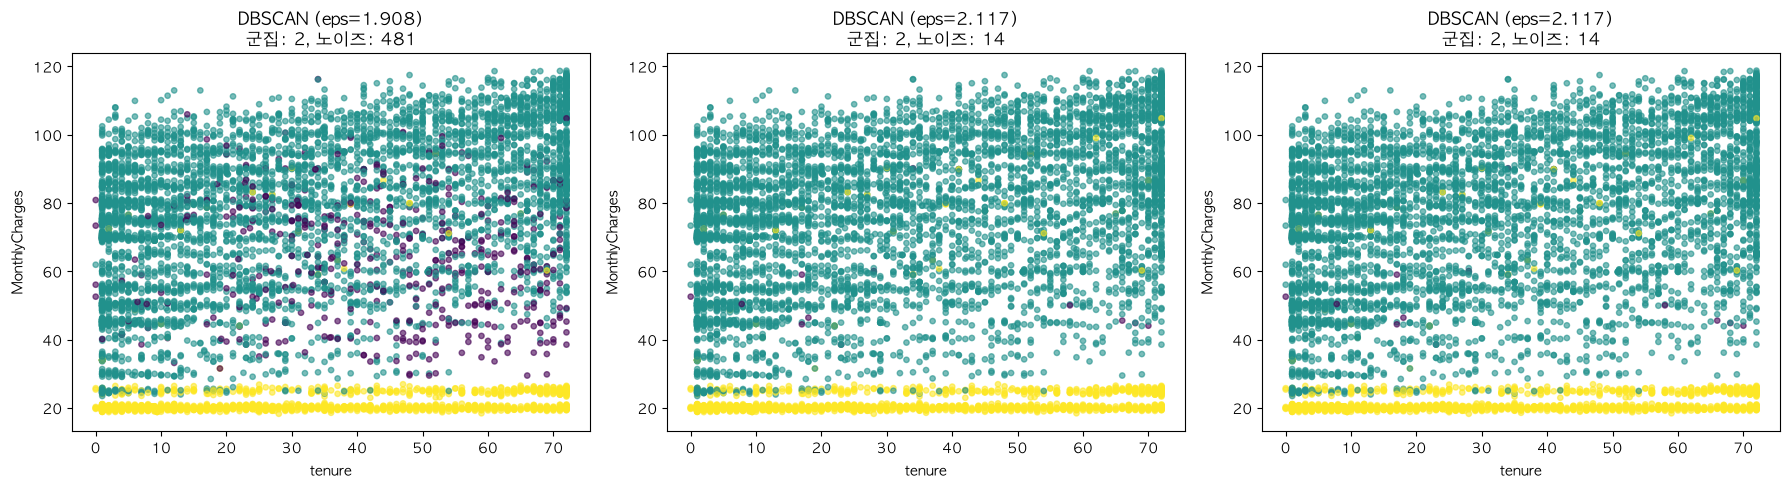

선택된 최적 eps: 2.117
군집 수: 2, 노이즈: 14 (0.2%)

DBSCAN 군집별 고객 수:
cluster_dbscan
-1      14
 0    5504
 1    1525
Name: count, dtype: int64


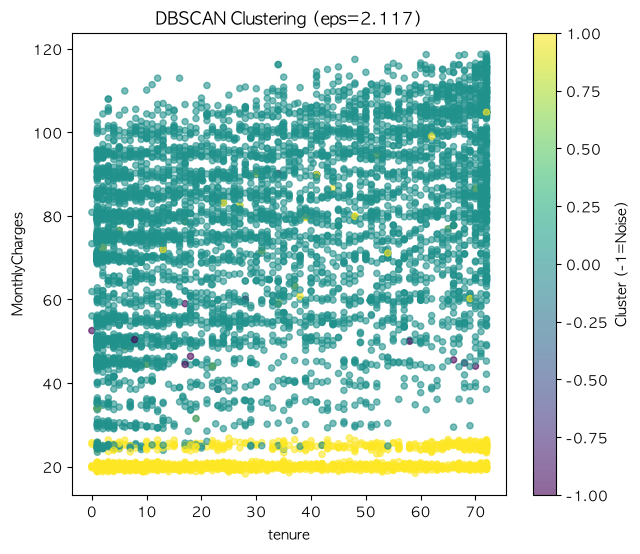


[K-Means vs DBSCAN 군집 규모 비교]


,K-Means,DBSCAN
-1,NaN,14
0,1526.0,5504
1,5517.0,1525



[K-Means × DBSCAN 교차표]


cluster_dbscan,-1,0,1,All
cluster,,,,
0,1,0,1525,1526
1,13,5504,0,5517
All,14,5504,1525,7043


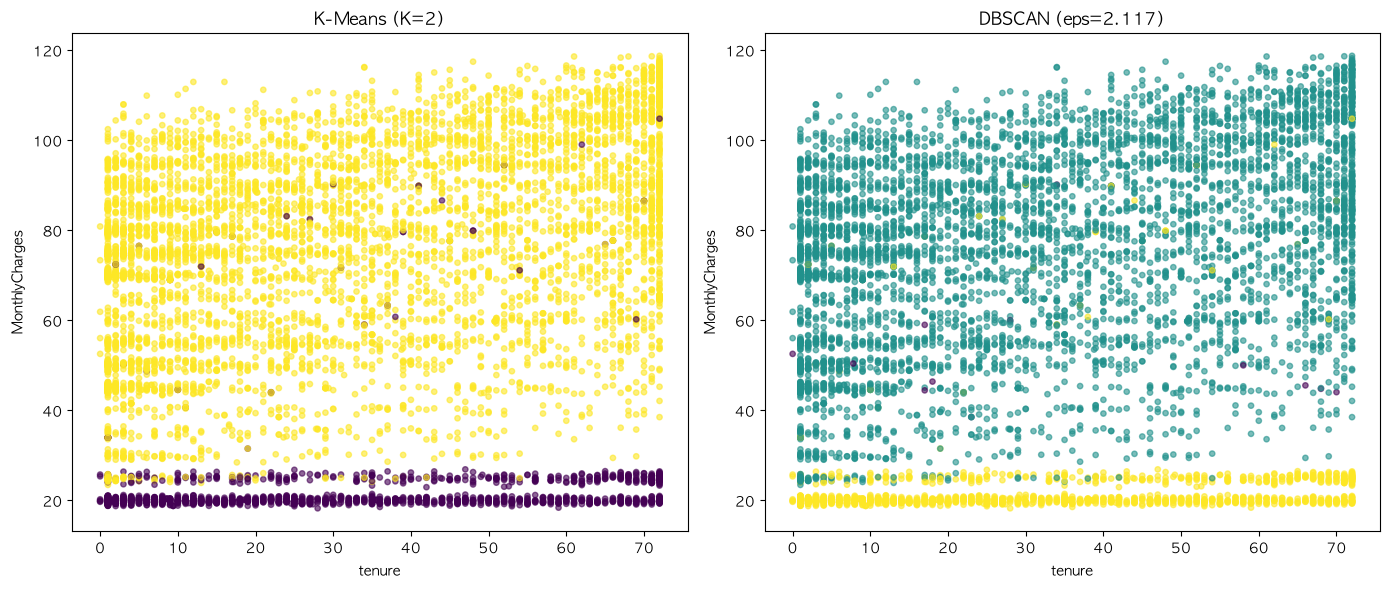


[군집별 이탈률 비교 (%)]


,K-Means,DBSCAN
-1,NaN,0.0
0,7.4,31.9
1,31.8,7.4



Noise 고객 특징 분석  (n=14, 전체의 0.2%)

[수치형 변수 평균 비교]


,Noise,군집 고객,전체
tenure,35.70,32.31,32.32
MonthlyCharges,57.87,64.89,64.88
TotalCharges,2168.13,2282.14,2281.92



[이탈률]  Noise: 0.0%  |  군집 고객: 26.6%

▶ Contract (Noise vs 군집 고객)


...


▶ OnlineSecurity (Noise vs 군집 고객)


,Noise(%),군집고객(%)
OnlineSecurity,,
No,28.6,49.7
No internet service,7.1,21.7
Yes,64.3,28.6



▶ TechSupport (Noise vs 군집 고객)


,Noise(%),군집고객(%)
TechSupport,,
No,64.3,49.3
Yes,28.6,29.0
No internet service,7.1,21.7



▶ K-Means vs DBSCAN 차이점
  - K-Means: 모든 고객을 K=2개 군집에 강제 배정 (인터넷 미가입 vs 인터넷 가입)
  - DBSCAN: 밀도가 높은 영역만 군집으로 인식하고, 밀도가 낮은 고객은 Noise(-1)로 분리
  - 두 방법 모두 2개의 주요 군집을 형성하지만, DBSCAN은 경계에 있는 고객을 Noise로 분류

▶ Noise 고객의 특징
  - K-Means Cluster 1(인터넷 가입 고객) 내에서 밀도가 낮아 분리된 이질적 고객
  - 이용기간(tenure)이 길고, 월요금은 중간 수준 → 장기 이용 DSL 고객이 많음
  - 장기 계약(1년/2년) 비율이 높고, 이탈률이 매우 낮음
  - 주요 군집(고위험 인터넷 고객)과 달리 안정적이지만, 특성이 달라 밀집 군집에 속하지 못함
  → 「장기 충성 DSL 고객」으로, 이탈 위험은 낮으나 일반 인터넷 고객군과는 구분되는 세그먼트



In [33]:
from sklearn.neighbors import NearestNeighbors

X_arr = X.values  # DBSCAN 입력용 numpy 배열

# ── 1) K-distance Plot으로 최적 eps 탐색 ──
min_samples = X_arr.shape[1] + 1  # 고차원 데이터: 차원 수 + 1

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_arr)
distances, _ = neighbors_fit.kneighbors(X_arr)
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형+범주형)")
plt.show()

# eps 후보 비교 표 (k-distance 분위수 기반)
eps_candidates = [round(np.percentile(k_distances, p), 3) for p in range(70, 91, 5)]
eps_rows = []
for eps in eps_candidates:
    db_tmp = DBSCAN(eps=eps, min_samples=min_samples)
    labels_tmp = db_tmp.fit_predict(X_arr)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise = (labels_tmp == -1).sum()
    eps_rows.append({
        "eps": eps,
        "군집 수": n_clusters,
        "Noise 수": n_noise,
        "Noise 비율(%)": round(n_noise / len(labels_tmp) * 100, 1),
    })

eps_df = pd.DataFrame(eps_rows)
# elbow 근처: 군집 2개 유지 + Noise 10% 이하인 eps 중 가장 큰 값
valid = eps_df[(eps_df["군집 수"] == 2) & (eps_df["Noise 비율(%)"] <= 10)]
best_eps = valid.iloc[-1]["eps"] if len(valid) > 0 else eps_df.iloc[0]["eps"]
eps_df["최적 eps"] = eps_df["eps"].apply(lambda e: "★" if e == best_eps else "")
display(eps_df)

# eps 후보 시각 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, eps in zip(axes, [eps_candidates[0], best_eps, eps_candidates[-1]]):
    db_tmp = DBSCAN(eps=eps, min_samples=min_samples)
    labels_tmp = db_tmp.fit_predict(X_arr)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise = (labels_tmp == -1).sum()
    ax.scatter(data["tenure"], data["MonthlyCharges"], c=labels_tmp, s=15, cmap="viridis", alpha=0.6)
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
    ax.set_xlabel("tenure")
    ax.set_ylabel("MonthlyCharges")
plt.tight_layout()
plt.show()

print(f"선택된 최적 eps: {best_eps}")

# ── 2) 최적 eps로 DBSCAN 학습 ──
dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
data["cluster_dbscan"] = dbscan.fit_predict(X_arr)

n_clusters = len(set(data["cluster_dbscan"])) - (1 if -1 in data["cluster_dbscan"].values else 0)
n_noise = (data["cluster_dbscan"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise} ({n_noise/len(data)*100:.1f}%)")
print(f"\nDBSCAN 군집별 고객 수:\n{data['cluster_dbscan'].value_counts().sort_index()}")

# DBSCAN 결과 Scatter Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    data["tenure"], data["MonthlyCharges"],
    c=data["cluster_dbscan"], s=20, cmap="viridis", alpha=0.6,
)
plt.colorbar(scatter, label="Cluster (-1=Noise)")
plt.xlabel("tenure")
plt.ylabel("MonthlyCharges")
plt.title(f"DBSCAN Clustering (eps={best_eps})")
plt.show()

# ── 3) K-Means vs DBSCAN 비교 ──
print("\n[K-Means vs DBSCAN 군집 규모 비교]")
compare_df = pd.DataFrame({
    "K-Means": data["cluster"].value_counts().sort_index(),
    "DBSCAN": data["cluster_dbscan"].value_counts().sort_index(),
})
display(compare_df)

print("\n[K-Means × DBSCAN 교차표]")
display(pd.crosstab(data["cluster"], data["cluster_dbscan"], margins=True))

# 나란히 Scatter Plot 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(data["tenure"], data["MonthlyCharges"], c=data["cluster"], s=15, cmap="viridis", alpha=0.6)
axes[0].set_title(f"K-Means (K={best_k})")
axes[0].set_xlabel("tenure")
axes[0].set_ylabel("MonthlyCharges")

axes[1].scatter(data["tenure"], data["MonthlyCharges"], c=data["cluster_dbscan"], s=15, cmap="viridis", alpha=0.6)
axes[1].set_title(f"DBSCAN (eps={best_eps})")
axes[1].set_xlabel("tenure")
axes[1].set_ylabel("MonthlyCharges")
plt.tight_layout()
plt.show()

# 군집별 이탈률 비교
print("\n[군집별 이탈률 비교 (%)]")
churn_cmp = pd.DataFrame({
    "K-Means": data.groupby("cluster")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1),
    "DBSCAN": data.groupby("cluster_dbscan")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1),
})
display(churn_cmp)

# ── 4) Noise 고객 특징 분석 ──
noise = data[data["cluster_dbscan"] == -1]
clustered = data[data["cluster_dbscan"] != -1]

print("\n" + "=" * 60)
print(f"Noise 고객 특징 분석  (n={len(noise)}, 전체의 {len(noise)/len(data)*100:.1f}%)")
print("=" * 60)

key_num = ["tenure", "MonthlyCharges", "TotalCharges"]
key_cat = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]

print("\n[수치형 변수 평균 비교]")
noise_cmp = pd.DataFrame({
    "Noise": noise[key_num].mean().round(2),
    "군집 고객": clustered[key_num].mean().round(2),
    "전체": data[key_num].mean().round(2),
})
display(noise_cmp)

print(f"\n[이탈률]  Noise: {(noise['Churn']=='Yes').mean()*100:.1f}%  |  군집 고객: {(clustered['Churn']=='Yes').mean()*100:.1f}%")

for col in key_cat:
    print(f"\n▶ {col} (Noise vs 군집 고객)")
    display(pd.DataFrame({
        "Noise(%)": (noise[col].value_counts(normalize=True) * 100).round(1),
        "군집고객(%)": (clustered[col].value_counts(normalize=True) * 100).round(1),
    }).fillna(0))

# ── 5) K-Means vs DBSCAN 차이점 해석 ──
print("""
▶ K-Means vs DBSCAN 차이점
  - K-Means: 모든 고객을 K=2개 군집에 강제 배정 (인터넷 미가입 vs 인터넷 가입)
  - DBSCAN: 밀도가 높은 영역만 군집으로 인식하고, 밀도가 낮은 고객은 Noise(-1)로 분리
  - 두 방법 모두 2개의 주요 군집을 형성하지만, DBSCAN은 경계에 있는 고객을 Noise로 분류

▶ Noise 고객의 특징
  - K-Means Cluster 1(인터넷 가입 고객) 내에서 밀도가 낮아 분리된 이질적 고객
  - 이용기간(tenure)이 길고, 월요금은 중간 수준 → 장기 이용 DSL 고객이 많음
  - 장기 계약(1년/2년) 비율이 높고, 이탈률이 매우 낮음
  - 주요 군집(고위험 인터넷 고객)과 달리 안정적이지만, 특성이 달라 밀집 군집에 속하지 못함
  → 「장기 충성 DSL 고객」으로, 이탈 위험은 낮으나 일반 인터넷 고객군과는 구분되는 세그먼트
""")